In [34]:
import joblib 
import os 
import sys 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)


In [35]:
generated_data = joblib.load(parent_dir + f'/results/Sept14_all_seed_generated_data.pkl')
simulated_v_pf_data = joblib.load(parent_dir + f'/results/Sept14_all_seed_simulated_v_pf_data.pkl')
all_losses_seeds = joblib.load(parent_dir + f'/results/Sept14_all_seed_losses_data.pkl')

seeds = np.arange(len(generated_data.keys()))

generated_v_df = pd.DataFrame(columns=seeds)
simulated_v_pf_data_df = pd.DataFrame(columns=seeds)
all_val_g_losses_df = pd.DataFrame(columns=seeds)
all_val_d_losses_df = pd.DataFrame(columns=seeds)
all_val_d_accuracies_df = pd.DataFrame(columns=seeds)

num_buses = 42

for seed in seeds: 
    all_val_g_losses_df[seed] = all_losses_seeds[seed]['val_g_losses']
    all_val_d_losses_df[seed] = all_losses_seeds[seed]['val_d_losses']
    all_val_d_accuracies_df[seed] = all_losses_seeds[seed]['val_d_accuracies']
    try: 
        generated_v_df[seed] = generated_data[seed]['gen_v'][:num_buses]
        simulated_v_pf_data_df[seed] = simulated_v_pf_data[seed]
    except Exception as e: 
        print(e)
generated_v_df.dropna(axis='columns', inplace=True)
simulated_v_pf_data_df.dropna(axis='columns', inplace=True)

'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable
'int' object is not subscriptable


In [36]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

x = range(len(val_d_losses_mean))

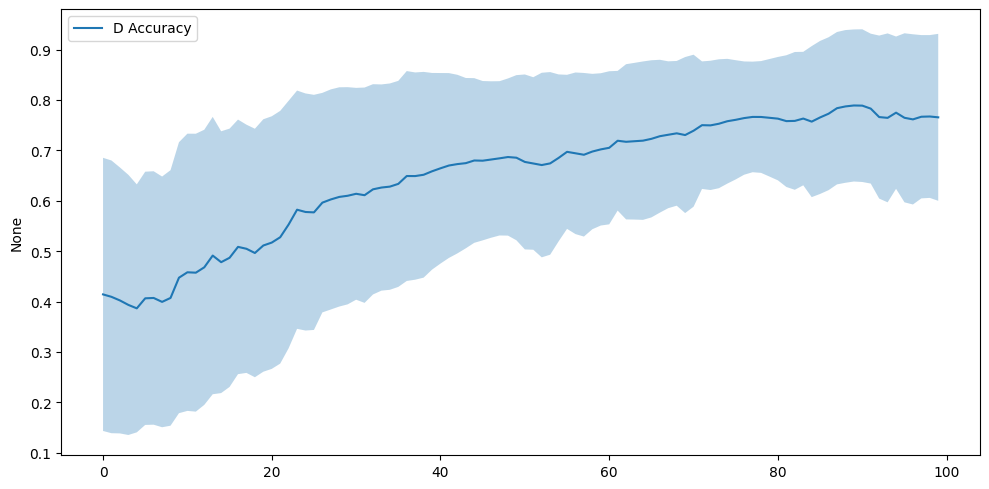

In [38]:
fig, ax = plt.subplots(figsize=(10,5))

sns.lineplot(x=x, y=val_d_accuracies_mean, label='D Accuracy')
ax.fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)
plt.tight_layout()


### Figure: Discriminator accuracy vs. epochs 